In [1]:
# Write your code here.
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [3]:
b_size = 128
lr = 0.001
epochs = 20
dr = 0.5

In [4]:
transform = transforms.Compose([transforms.RandomRotation(20), transforms.RandomAffine(degrees=0, scale = (0.9, 1.1)), transforms.ToTensor(), transforms.Normalize((0.5,), (0.5,))])

In [5]:
train_ds = datasets.MNIST(root = "./data", train = True, transform = transform, download = True)
test_ds = datasets.MNIST(root = "./data", train = False, transform = transform, download = True)


Failed to download (trying next):
<urlopen error [Errno 111] Connection refused>



100%|██████████| 9.91M/9.91M [00:00<00:00, 10.5MB/s]


Extracting ./data/MNIST/raw/train-images-idx3-ubyte.gz to ./data/MNIST/raw

Failed to download (trying next):
<urlopen error [Errno 111] Connection refused>



100%|██████████| 28.9k/28.9k [00:00<00:00, 366kB/s]


Extracting ./data/MNIST/raw/train-labels-idx1-ubyte.gz to ./data/MNIST/raw

Failed to download (trying next):
<urlopen error [Errno 111] Connection refused>



100%|██████████| 1.65M/1.65M [00:00<00:00, 2.80MB/s]


Extracting ./data/MNIST/raw/t10k-images-idx3-ubyte.gz to ./data/MNIST/raw

Failed to download (trying next):
<urlopen error [Errno 111] Connection refused>



100%|██████████| 4.54k/4.54k [00:00<00:00, 7.26MB/s]

Extracting ./data/MNIST/raw/t10k-labels-idx1-ubyte.gz to ./data/MNIST/raw



In [6]:
train_loader = DataLoader(dataset = train_ds, batch_size = b_size, shuffle = True)
test_loader = DataLoader(dataset = test_ds, batch_size = b_size, shuffle = False)


In [7]:
class MLP(nn.Module):
  def __init__(self, input_size, hidder_layer, n_classes, dr):
    super(MLP, self).__init__()
    self.layers = []
    prev = input_size
    for hidden_size in hidder_layer:
      self.layers.append(nn.Linear(prev, hidden_size))
      self.layers.append(nn.BatchNorm1d(hidden_size))
      self.layers.append(nn.ReLU())
      self.layers.append(nn.Dropout(dr))
      prev = hidden_size
    self.layers.append(nn.Linear(prev, n_classes))
    self.model = nn.Sequential(*self.layers)
  def forward(self, x):
    return self.model(x)

In [8]:
input_size = 784
hidden_layer = [256, 128, 64]
n_classes = 10
model = MLP(input_size, hidden_layer, n_classes, dr).to(device)

In [9]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr)

In [10]:
def train(model, loader, criterion, optimizer):
  model.train()
  total_loss = 0
  corr = 0
  for images, labels in loader:
    images = images.view(-1, 784).to(device)
    labels = labels.to(device)
    optimizer.zero_grad()
    y_pred = model(images)
    loss = criterion(y_pred, labels)
    loss.backward()
    optimizer.step()
    total_loss += loss.item()
    _, pred = torch.max(y_pred, 1)
    corr += (pred==labels).sum().item()
  acc = 100*corr/len(loader.dataset)
  return total_loss/len(loader), acc


In [11]:
def evaluate(model, loader, criterion):
  model.eval()
  total_loss = 0
  corr = 0
  all_labels = []
  all_pred = []
  with torch.no_grad():
    for images, labels in loader:
      images = images.view(-1, 784).to(device)
      labels = labels.to(device)
      y_pred = model(images)
      loss = criterion(y_pred, labels)
      total_loss += loss.item()
      _, pred = torch.max(y_pred, 1)
      corr += (pred==labels).sum().item()
      all_labels.extend(labels.cpu().numpy())
      all_pred.extend(pred.cpu().numpy())
  acc = 100*corr/len(loader.dataset)
  return total_loss/len(loader), acc, all_labels, all_pred

In [17]:
def initialize_weights(m):
    if isinstance(m, nn.Linear):
        nn.init.kaiming_uniform_(m.weight, nonlinearity='relu')
        if m.bias is not None:
            nn.init.constant_(m.bias, 0)

model.apply(initialize_weights)

MLP(
  (model): Sequential(
    (0): Linear(in_features=784, out_features=256, bias=True)
    (1): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.5, inplace=False)
    (4): Linear(in_features=256, out_features=128, bias=True)
    (5): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.5, inplace=False)
    (8): Linear(in_features=128, out_features=64, bias=True)
    (9): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): Dropout(p=0.5, inplace=False)
    (12): Linear(in_features=64, out_features=10, bias=True)
  )
)

In [12]:
for epoch in range(epochs):
  train_loss, train_accuracy = train(model, train_loader, criterion, optimizer)
  test_loss, test_accuracy, _, _ = evaluate(model, test_loader, criterion)

  print(f"Epoch [{epoch+1}/{epochs}] - Train Loss: {train_loss:.4f}, Train Accuracy: {train_accuracy:.2f}% \
        Test Loss: {test_loss:.4f}, Test Accuracy: {test_accuracy:.2f}%")

Epoch [1/20] - Train Loss: 0.8463, Train Accuracy: 75.42%         Test Loss: 0.2788, Test Accuracy: 91.96%
Epoch [2/20] - Train Loss: 0.4708, Train Accuracy: 86.60%         Test Loss: 0.2037, Test Accuracy: 93.76%
Epoch [3/20] - Train Loss: 0.3927, Train Accuracy: 88.82%         Test Loss: 0.1683, Test Accuracy: 94.78%
Epoch [4/20] - Train Loss: 0.3531, Train Accuracy: 90.03%         Test Loss: 0.1504, Test Accuracy: 95.44%
Epoch [5/20] - Train Loss: 0.3195, Train Accuracy: 91.14%         Test Loss: 0.1472, Test Accuracy: 95.57%
Epoch [6/20] - Train Loss: 0.3059, Train Accuracy: 91.44%         Test Loss: 0.1300, Test Accuracy: 96.03%
Epoch [7/20] - Train Loss: 0.2894, Train Accuracy: 91.89%         Test Loss: 0.1222, Test Accuracy: 96.23%
Epoch [8/20] - Train Loss: 0.2769, Train Accuracy: 92.44%         Test Loss: 0.1096, Test Accuracy: 96.65%
Epoch [9/20] - Train Loss: 0.2677, Train Accuracy: 92.69%         Test Loss: 0.1125, Test Accuracy: 96.56%
Epoch [10/20] - Train Loss: 0.2550, T


Classification Report:
               precision    recall  f1-score   support

           0       0.97      0.99      0.98       980
           1       0.99      0.99      0.99      1135
           2       0.98      0.97      0.98      1032
           3       0.97      0.97      0.97      1010
           4       0.98      0.97      0.97       982
           5       0.97      0.98      0.97       892
           6       0.98      0.98      0.98       958
           7       0.97      0.97      0.97      1028
           8       0.97      0.95      0.96       974
           9       0.97      0.97      0.97      1009

    accuracy                           0.97     10000
   macro avg       0.97      0.97      0.97     10000
weighted avg       0.98      0.97      0.97     10000



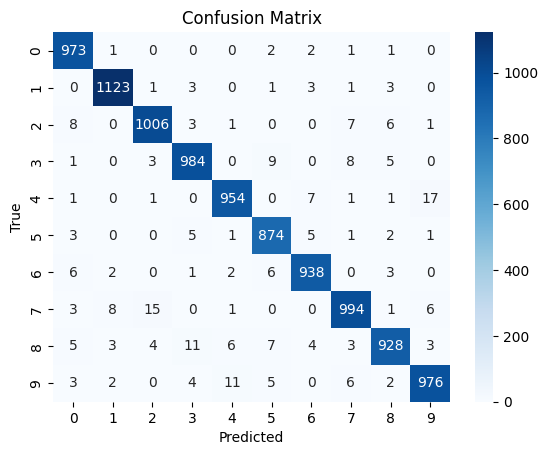

In [13]:
_, _, labels, predictions = evaluate(model, test_loader, criterion)

report = classification_report(labels, predictions, target_names=[str(i) for i in range(10)])
print("\nClassification Report:\n", report)

# Confusion matrix
cm = confusion_matrix(labels, predictions)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=range(10), yticklabels=range(10))
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()


In [18]:
def hyperparameter_tuning():
    from itertools import product
    dropout_rates = [0.3, 0.5, 0.7]
    learning_rates = [0.001, 0.005, 0.01]
    hidden_layer_sizes = [[256, 128, 64], [512, 256, 128], [512, 256, 128, 64]]

    best_model = None
    best_accuracy = 0
    best_params = None

    for dropout_rate, lr, hidden_sizes in product(dropout_rates, learning_rates, hidden_layer_sizes):
        print(f"Testing configuration: Dropout={dropout_rate}, LR={lr}, Hidden Sizes={hidden_sizes}")
        model = MLP(input_size, hidden_sizes, n_classes, dropout_rate).to(device)
        model.apply(initialize_weights)
        optimizer = optim.Adam(model.parameters(), lr=lr)
        for epoch in range(10):
            train_loss, train_accuracy = train(model, train_loader, criterion, optimizer)
        _, test_accuracy, _, _ = evaluate(model, test_loader, criterion)

        if test_accuracy > best_accuracy:
            best_accuracy = test_accuracy
            best_model = model
            best_params = (dropout_rate, lr, hidden_sizes)

    print(f"Best configuration: Dropout={best_params[0]}, LR={best_params[1]}, Hidden Sizes={best_params[2]}")
    print(f"Best Test Accuracy: {best_accuracy:.2f}%")

    return best_model, best_params


In [19]:
hyperparameter_tuning()

Testing configuration: Dropout=0.3, LR=0.001, Hidden Sizes=[256, 128, 64]
Testing configuration: Dropout=0.3, LR=0.001, Hidden Sizes=[512, 256, 128]
Testing configuration: Dropout=0.3, LR=0.001, Hidden Sizes=[512, 256, 128, 64]
Testing configuration: Dropout=0.3, LR=0.005, Hidden Sizes=[256, 128, 64]
Testing configuration: Dropout=0.3, LR=0.005, Hidden Sizes=[512, 256, 128]
Testing configuration: Dropout=0.3, LR=0.005, Hidden Sizes=[512, 256, 128, 64]
Testing configuration: Dropout=0.3, LR=0.01, Hidden Sizes=[256, 128, 64]
Testing configuration: Dropout=0.3, LR=0.01, Hidden Sizes=[512, 256, 128]
Testing configuration: Dropout=0.3, LR=0.01, Hidden Sizes=[512, 256, 128, 64]
Testing configuration: Dropout=0.5, LR=0.001, Hidden Sizes=[256, 128, 64]
Testing configuration: Dropout=0.5, LR=0.001, Hidden Sizes=[512, 256, 128]
Testing configuration: Dropout=0.5, LR=0.001, Hidden Sizes=[512, 256, 128, 64]
Testing configuration: Dropout=0.5, LR=0.005, Hidden Sizes=[256, 128, 64]
Testing configura

(MLP(
   (model): Sequential(
     (0): Linear(in_features=784, out_features=512, bias=True)
     (1): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
     (2): ReLU()
     (3): Dropout(p=0.3, inplace=False)
     (4): Linear(in_features=512, out_features=256, bias=True)
     (5): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
     (6): ReLU()
     (7): Dropout(p=0.3, inplace=False)
     (8): Linear(in_features=256, out_features=128, bias=True)
     (9): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
     (10): ReLU()
     (11): Dropout(p=0.3, inplace=False)
     (12): Linear(in_features=128, out_features=10, bias=True)
   )
 ),
 (0.3, 0.005, [512, 256, 128]))